# UC-00 — Work in the engineer's own measurement units

**Use case:** [UC-00](../docs/product/use-cases.md) — the foundational *use case zero*.
This is the units/fluids layer every other use case stands on: before any head,
power, efficiency, or affinity result means anything, the raw readings an engineer
transcribes from gauges and datasheets — in whatever mixed units the instruments
report — have to land on the project's **standard units**, and convert back to the
engineer's display units without loss.

This notebook is also the consolidated home of the old *"Library import and
utilities demonstration"* dev workbench (it absorbs `tests/01_utilities_test.ipynb`).

| Utility | Module | What it does |
|---|---|---|
| `quantity_factory` | `pump.utilities.unit_conversion` | Single entry point that normalises a Pint quantity to its project-standard unit |
| `Q_` | `pump.utilities.unit_conversion` | Pint `Quantity` constructor, re-exported for convenience |
| `Fluid` | `pump.utilities.fluid` | Immutable fluid descriptor (name + density + optional extras) |
| `Water` | `pump.utilities.fluid` | `Fluid` subclass: density computed from temperature via a 4th-order polynomial |

**Acceptance** (UC-00): a value entered in any dimensionally-compatible unit
normalises to its standard unit and round-trips back **without loss**. The notebook
asserts this; if a cell raises, the units spine has regressed.

> Charter note: this is a [`use_cases/`](README.md) gallery example — it imports
> **`pump`** plus `numpy`/`matplotlib` only, never `pumpflow`, and runs top to
> bottom under *Restart & Run All*.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pump import *  # Q_, quantity_factory, Fluid, Water, STANDARD_UNITS, ...

## 2. Inputs — a FAT test sheet, as transcribed

A real test sheet arrives in whatever each instrument reports: capacity in US
gallons per minute, suction in bar, discharge in psi, the differential in bar,
the barometer in atm, speed in rpm, water temperature in °C. We tag each magnitude
with its **native** unit and its **context** (see §3 on context), then let the
library do the normalising — no hand conversions.

In [2]:
# test water at the measured temperature (density from the Water polynomial)
fluid = Water(Q_(34.0, "degC"))

# (reading, context) exactly as the engineer would key them in
readings = {
    "capacity":           (Q_(420.0, "gallon/min"), "default"),
    "suction_pressure":   (Q_(0.8, "bar"),          "default"),
    "discharge_pressure": (Q_(95.0, "psi"),         "default"),
    "differential":       (Q_(6.2, "bar"),          "delta"),
    "barometric":         (Q_(1.0, "atm"),          "atm"),
    "speed":              (Q_(2950.0, "rpm"),       "default"),
    "fluid_temperature":  (Q_(34.0, "degC"),        "default"),
}
print(f"Test fluid: {fluid}  (rho = {fluid.density:~P})")

Test fluid: Fluid(name=Water, density=994.3690212194624 kilogram / meter ** 3, temperature=307.15 kelvin)  (rho = 994.3690212194624 kg/m³)


## 3. Normalise through the single entry point

`quantity_factory(q, context)` is the **one** place quantities become standard
([CLAUDE.md — "the units spine"](../CLAUDE.md)). It dispatches on dimensionality
against `STANDARD_UNITS` and returns a fresh quantity in the project-standard unit.

In [3]:
normalized = {name: quantity_factory(q, ctx) for name, (q, ctx) in readings.items()}

for name, (q, ctx) in readings.items():
    print(f"{name:20s} {q:~P:>14}  --[{ctx}]-->  {normalized[name]:~P}")

capacity             :::::::::420.0 gal/min  --[default]-->  95.39237695679998 m³/h
suction_pressure     :::::::::::0.8 bar  --[default]-->  0.8157729703823426 kgf/cm²
discharge_pressure   ::::::::::95.0 psi  --[default]-->  6.6791610065720155 kgf/cm²
differential         :::::::::::6.2 bar  --[delta]-->  6.2 bar
barometric           :::::::::::1.0 atm  --[atm]-->  101325.0 Pa
speed                ::::::::2950.0 rpm  --[default]-->  2950.0 rpm
fluid_temperature    ::::::::::34.0 °C  --[default]-->  307.15 K


### The `context` parameter

Some quantities are expressed in **different units depending on what they
represent**, not just their magnitude. Pressure is the canonical pump example:

| Context | Target unit | When to use |
|---|---|---|
| `"default"` | `kgf/cm²` | Gauge or absolute reading on a datasheet |
| `"atm"` | `pascal` | Atmospheric reference level |
| `"delta"` | `bar` | Differential pressure across a restriction or the pump |

You rarely pass `context` by hand: `extract_context` infers it from attribute
names — the leading token of `delta_pressure` matches the known context set and is
forwarded automatically. Choose prefixes that are *not* context names
(`inlet_…`, `outlet_…`) when you want the default unit regardless of position.

## 3b. `Fluid` and `Water`

`Fluid` is a generic descriptor; extra kwargs (viscosity, …) ride along as Pint
attributes. `Water` derives density from temperature, so any temperature unit and
two equal temperatures give one fluid.

In [4]:
oil = Fluid(name="Light crude oil", density=Q_(850, "kg/m**3"), viscosity=Q_(10, "cP"))
print(oil)
print("  density  :", oil.density)
print("  viscosity:", oil.viscosity)

print("\nWater(20 °C) == Water(293.15 K):",
      Water(Q_(20.0, "degC")) == Water(Q_(293.15, "K")))

Fluid(name=Light crude oil, density=850 kilogram / meter ** 3, viscosity=10 centipoise)
  density  : 850 kilogram / meter ** 3
  viscosity: 10 centipoise

Water(20 °C) == Water(293.15 K): True


## 4. Acceptance — normalise, then round-trip back without loss

The UC-00 guarantee: normalising and converting back to the entry unit returns the
original magnitude (to floating-point tolerance) for **every** reading.

In [5]:
failures = []
for name, (q, ctx) in readings.items():
    back = normalized[name].to(q.units)          # standard -> original entry unit
    if not np.isclose(back.magnitude, q.magnitude, rtol=1e-9, atol=1e-9):
        failures.append((name, q, back))

assert not failures, f"round-trip lost precision: {failures}"
print(f"UC-00 acceptance: {len(readings)} readings normalised & round-tripped losslessly  OK")

UC-00 acceptance: 7 readings normalised & round-tripped losslessly  OK


## 5. Plot — the `Water` density polynomial

A small visual of the utility behind the test fluid: density vs temperature, with
the test water (34 °C) marked.

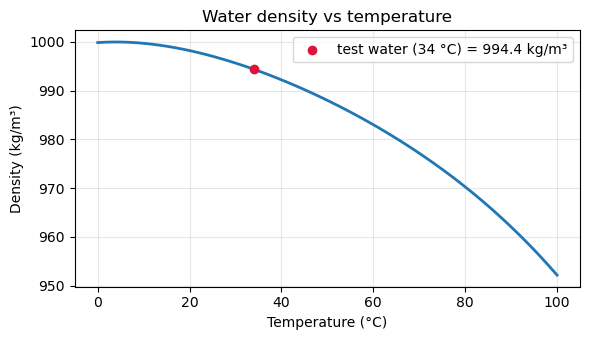

In [6]:
temps = np.linspace(0, 100, 60)
dens = [Water(Q_(t, "degC")).density.magnitude for t in temps]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(temps, dens, lw=2)
ax.scatter([34.0], [fluid.density.magnitude], color="crimson", zorder=5,
           label=f"test water (34 °C) = {fluid.density.magnitude:.1f} kg/m³")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density (kg/m³)")
ax.set_title("Water density vs temperature")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Readout

Every reading is now on a project-standard unit and unit-consistent — the
substrate UC-02 (verify performance), UC-06 (speed change) and UC-09 (report) all
build on.

In [7]:
print("Normalized to project-standard units:")
for name, q in normalized.items():
    print(f"  {name:20s} {q:~P}")

Normalized to project-standard units:
  capacity             95.39237695679998 m³/h
  suction_pressure     0.8157729703823426 kgf/cm²
  discharge_pressure   6.6791610065720155 kgf/cm²
  differential         6.2 bar
  barometric           101325.0 Pa
  speed                2950.0 rpm
  fluid_temperature    307.15 K
